В данной работе проводится обработка результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель билинейного изотропного упрочнения - **BISO**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [67]:
model_name = "BISO"

nu_path = r'nu.txt'
with open(nu_path, 'r') as f:
        nu = float(f.read().strip())
nu

0.499999999999

In [84]:
a_path = r'a.txt'
with open(a_path, 'r') as f:
        a = float(f.read().strip())

c_path = r'c.txt'
with open(c_path, 'r') as f:
        c = float(f.read().strip())

n_turns_path = r'n_turns.txt'
with open(n_turns_path, 'r') as f:
        n_turns = float(f.read().strip())

a, c, n_turns

(0.0157, 0.0025, 2.0)

In [68]:
from core.reader import read_ansys_csv

numerical_experiment_data_biso = r'biso.csv'
numerical_experiment_biso = read_ansys_csv(numerical_experiment_data_biso)

### 1. Первичный обзор данных
Проверим структуру загруженного DataFrame. Данные содержат временные метки, компоненты тензоров деформаций (упругих `EPEL`, пластических `EPPL`, полных `EPTO`), напряжений (`S`), а также интенсивность деформаций и параметр Одквиста.

In [69]:
numerical_experiment_biso.sample(3, random_state=42)

,Time,EPEL_TT,EPPL_TT,EPTO_TT,EPEL_ZZ,EPPL_ZZ,EPTO_ZZ,EPEL_TZ,EPPL_TZ,EPTO_TZ,EPEL_RR,EPPL_RR,EPTO_RR,S_TT,S_ZZ,S_TZ,S_EQV,EPPL_EQV,NL_EPEQ
3207,213.7178,0.002053,0.002113,0.004166,-0.000847,0.006201,0.005353,0.001637,0.002650,0.004287,-0.001206,-0.008313,-0.009519,445.3351,48.94823,111.8520,465.2457,0.008776,0.010011
5890,392.5178,0.001890,0.008390,0.010280,-0.000221,0.003070,0.002848,-0.002790,0.000585,-0.002205,-0.001669,-0.011460,-0.013129,486.3062,197.78590,-190.6354,537.0791,0.011870,0.016844
8814,587.4178,0.001369,0.011902,0.013270,0.001423,0.006046,0.007469,0.001870,-0.002552,-0.000682,-0.002791,-0.017948,-0.020739,568.5148,575.93260,127.7818,613.5681,0.018322,0.024120


### 2. Графики полных деформаций
Построим графики изменения компонент тензора полных деформаций от времени.
* `EPTO_ZZ` — осевая деформация ($\varepsilon_z$).
* `EPTO_TT` — окружная деформация ($\varepsilon_\theta$).
* `EPTO_TZ` — деформация сдвига ($\varepsilon_{\theta z}$).

На первом этапе (растяжение) должна меняться только $\varepsilon_z$. На втором этапе (винт) должны меняться все компоненты.

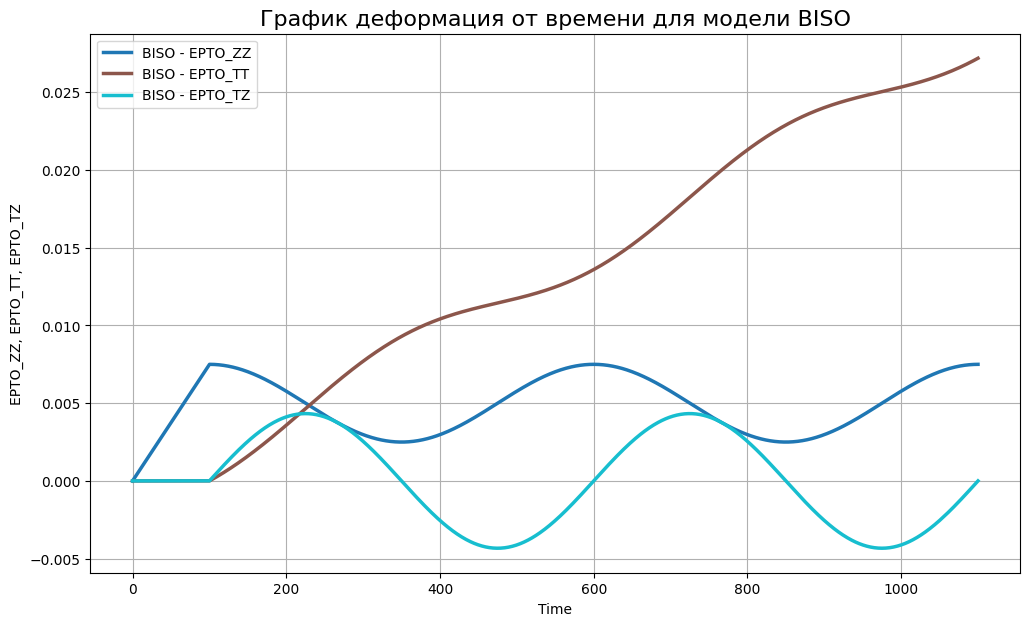

In [70]:
from core.visualizer import plot_xy

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'График деформация от времени для модели {model_name}'
)


### 3. Расчет вектора деформаций Ильюшина
Для анализа сложных процессов деформирования перейдем от тензорного представления к векторному в пятимерном евклидовом пространстве А.А. Ильюшина $E^5$.

Компоненты вектора деформаций $\bar{\ni}$ линейно выражаются через компоненты тензора деформаций. Для случая тонкостенного трубчатого образца (где $\varepsilon_{11} = \varepsilon_z$ — осевая, $\varepsilon_{22} = \varepsilon_\theta$ — окружная, $\varepsilon_{12} = \varepsilon_{\theta z}$ — сдвиговая) формулы принимают вид:

$$ \ni_1 = \varepsilon_z - \varepsilon_{mean}$$
$$ \ni_2 = \frac{1}{\sqrt{3}} ((\varepsilon_z - \varepsilon_{mean}) + 2(\varepsilon_\theta - \varepsilon_{mean})) $$
$$ \ni_3 = \frac{2}{\sqrt{3}} \varepsilon_{\theta z} $$

Это позволяет нам анализировать траекторию деформирования как кривую в векторном пространстве, вычислять ее кривизну и угол сближения.

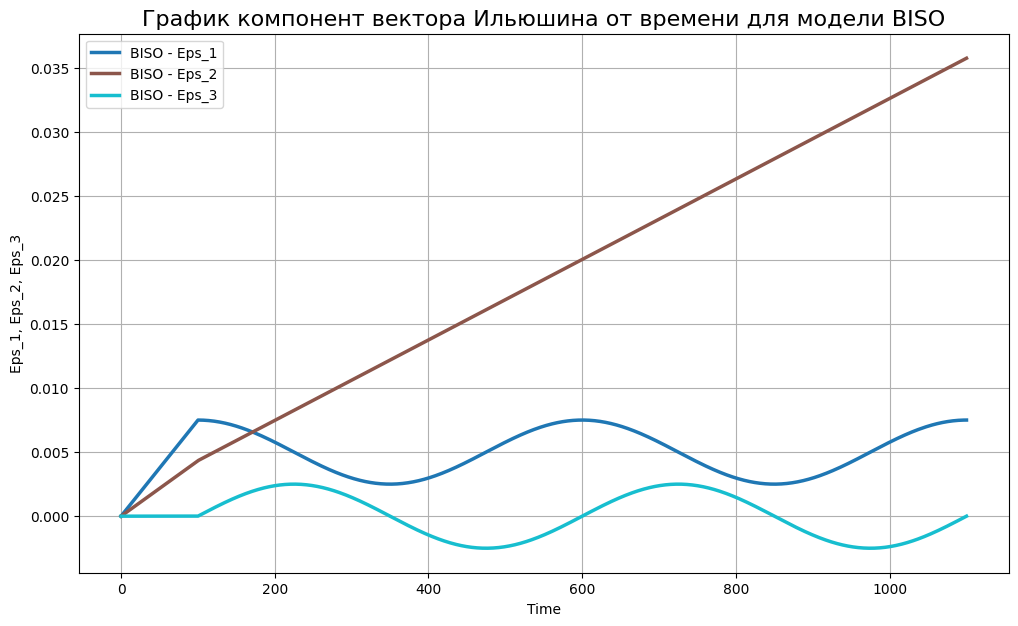

In [71]:
from core.calculations import calculate_ilushin_strain_vector


numerical_experiment_biso_strain_vector = calculate_ilushin_strain_vector(
    numerical_experiment_biso,
    compressible = abs(nu - 0.5) >= 1e-6
)

plot_xy([
        (model_name, numerical_experiment_biso_strain_vector)
    ],
    'Time',
    ['Eps_1', 'Eps_2', 'Eps_3'],
    f'График компонент вектора Ильюшина от времени для модели {model_name}'
)

### 4. Разделение этапов деформирования
Процесс нагружения состоит из двух этапов:
1.  **Одноосное растяжение** (прямолинейный участок траектории).
2.  **Сложное нагружение** (винтовая траектория).

Нам необходимо выделить данные, относящиеся только ко второму этапу, так как именно на нем исследуются эффекты сложного деформирования (кручение, кривизна траектории). Момент окончания первого этапа считываем из файла конфигурации `steps_n1.txt`.

In [72]:
step_n1_path = r'steps_n1.txt'
with open(step_n1_path, 'r') as f:
        split_time = float(f.read().strip())
split_time

100.0

In [73]:
df_stage2 = numerical_experiment_biso_strain_vector[
    numerical_experiment_biso_strain_vector['Time'] > split_time
].copy()

df_stage2.reset_index(drop=True, inplace=True)
df_stage2['Time_Local'] = df_stage2['Time'] - split_time

In [74]:
df_stage2[:10]

,Time,Eps_1,Eps_2,Eps_3,Time_Local
0,100.0100,0.0075,0.004330,3.141510e-07,0.0100
1,100.0200,0.0075,0.004331,6.283020e-07,0.0200
2,100.0350,0.0075,0.004331,1.099528e-06,0.0350
3,100.0575,0.0075,0.004332,1.806368e-06,0.0575
4,100.0913,0.0075,0.004333,2.866628e-06,0.0913
5,100.1419,0.0075,0.004335,4.457018e-06,0.1419
6,100.2178,0.0075,0.004337,6.842600e-06,0.2178
7,100.3178,0.0075,0.004340,9.984112e-06,0.3178
8,100.4178,0.0075,0.004343,1.312562e-05,0.4178
9,100.5178,0.0075,0.004346,1.626713e-05,0.5178


### 5. Аналитическое решение для скоростей деформаций

Для проверки точности численных методов и нейросети мы используем аналитическое решение. Траектория деформирования на втором этапе представляет собой винтовую линию и задается следующими параметрическими уравнениями зависимости деформаций от угла поворота $\alpha$:

**1. Уравнения траектории (зависимость от $\alpha$):**
$$ \varepsilon_z(\alpha) = c \cdot (\cos\alpha - 1) + \varepsilon_{z_0} $$
$$ \varepsilon_\theta(\alpha) = \frac{\sqrt{3}}{2} a \left(\frac{\alpha}{2\pi}\right) - \frac{1}{2} c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_{\theta z}(\alpha) = \frac{\sqrt{3}}{2} c \cdot \sin\alpha $$

где:
*   $c$ — радиус цилиндра траектории в пространстве деформаций.
*   $a$ — шаг винтовой линии.
*   $\alpha(t) = \omega \cdot t$ — угол поворота, линейно зависящий от времени ($\omega = const$).

**2. Скорости деформаций (производные по времени):**
Дифференцируя уравнения траектории по времени ($\frac{d}{dt} = \frac{d}{d\alpha} \frac{d\alpha}{dt}$), получаем:

$$ \dot{\varepsilon}_z = -c \cdot \sin\alpha \cdot \omega $$
$$ \dot{\varepsilon}_\theta = \left( \frac{\sqrt{3} a}{4\pi} + \frac{1}{2} c \cdot \sin\alpha \right) \cdot \omega $$
$$ \dot{\varepsilon}_{\theta z} = \frac{\sqrt{3}}{2} c \cdot \cos\alpha \cdot \omega $$

**3. Вектор скоростей деформаций Ильюшина:**

Для тонкостенной трубки мы принимаем гипотезу **плоского напряженного состояния** ($\sigma_r = 0$).

1. **Связь радиальной деформации с остальными:**
    Из закона Гука следует, что деформация по толщине стенки ($\varepsilon_r$) зависит от осевой ($\varepsilon_z$) и окружной ($\varepsilon_\theta$):
    $$ \varepsilon_r = -\frac{\nu}{1-\nu} (\varepsilon_z + \varepsilon_\theta) $$

2.  **Средняя деформация (изменение объема):**
    $$ \varepsilon_{mean} = \frac{1}{3} (\varepsilon_z + \varepsilon_\theta + \varepsilon_r) $$
    Подставив $\varepsilon_r$, получаем:
    $$ \varepsilon_{mean} = \frac{1-2\nu}{3(1-\nu)} (\varepsilon_z + \varepsilon_\theta) $$

3.  **Вектор скоростей Ильюшина:**
    Подставляя найденные производные в формулы связи векторного и тензорного представлений, получаем итоговые выражения для компонент вектора скорости $\dot{\bar{\ni}}$:

    $$ \dot{\ni}_1 = \dot{\varepsilon}_z - \dot{\varepsilon}_{mean} $$
    
    $$ \dot{\ni}_2 = \frac{1}{\sqrt{3}} \left[ (\dot{\varepsilon}_z - \dot{\varepsilon}_{mean}) + 2(\dot{\varepsilon}_\theta - \dot{\varepsilon}_{mean}) \right] = \frac{1}{\sqrt{3}} (\dot{\varepsilon}_z + 2\dot{\varepsilon}_\theta - 3\dot{\varepsilon}_{mean}) $$
    
    $$ \dot{\ni}_3 = \frac{2}{\sqrt{3}} \dot{\varepsilon}_{\theta z} $$

Эти формулы позволяют вычислить точное значение производной в любой точке $t$ и использовать его как эталон для оценки ошибки MSE.

In [75]:
step_n2_path = r'steps_n2.txt'
with open(step_n2_path, 'r') as f:
        steps_n2 = float(f.read().strip())
steps_n2

1000.0

Угловая скорость на винтовой траектории omega: 0.0126


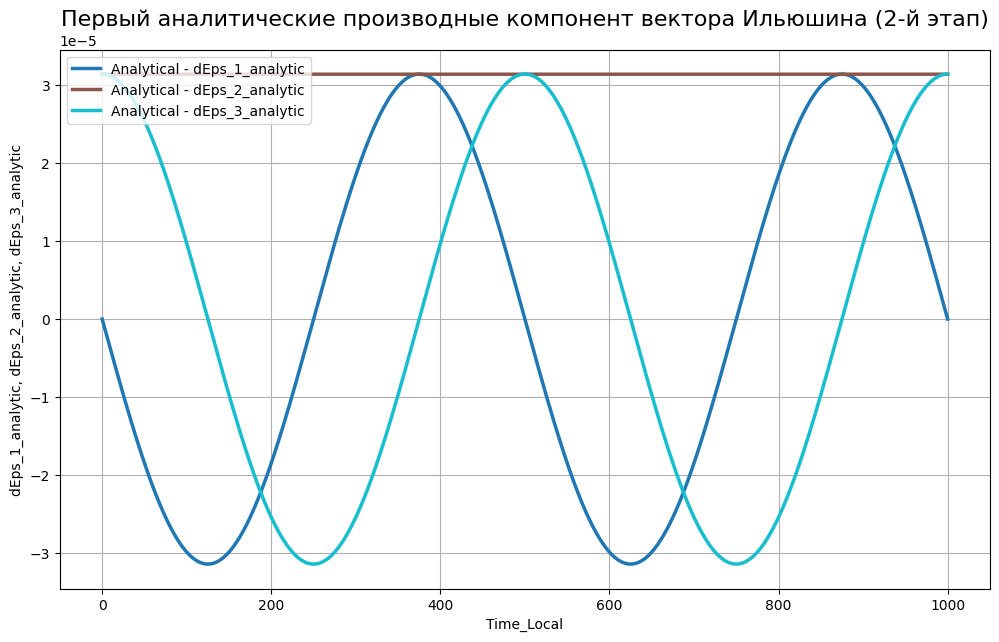

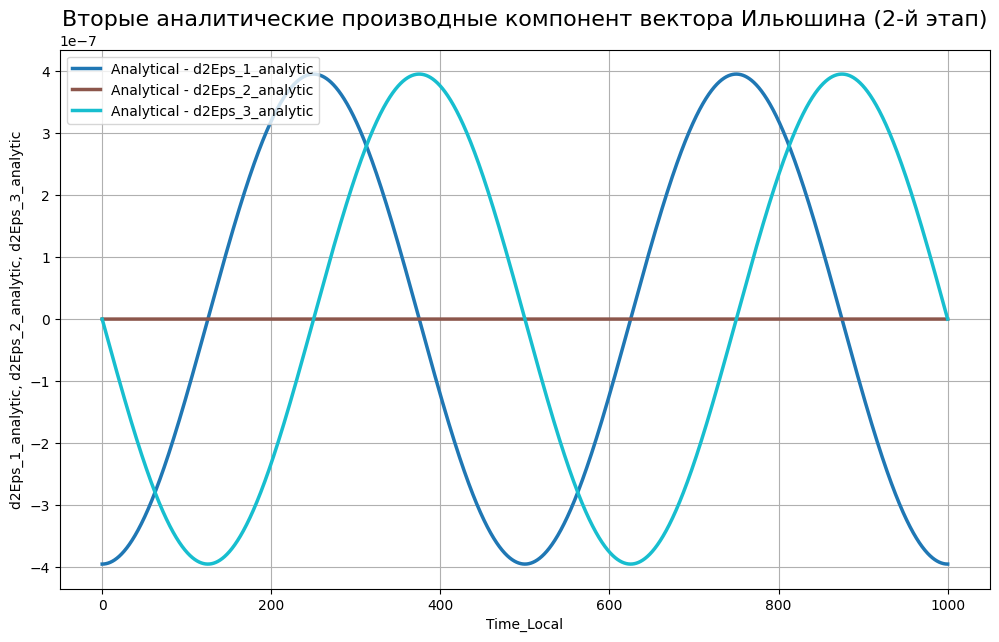

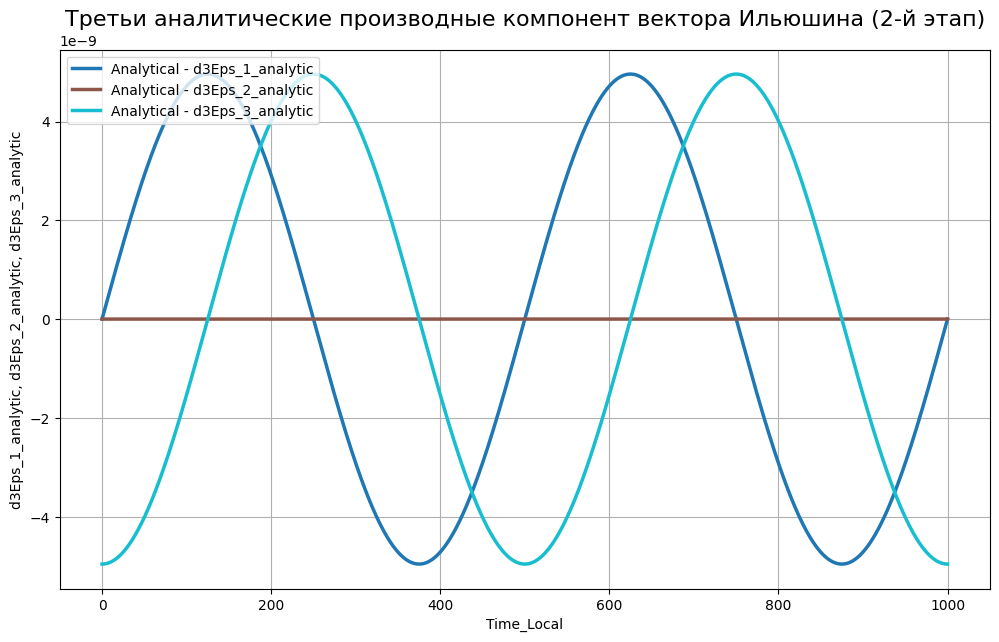

In [ ]:
from core.derivatives.analytical import AnalyticalDerivatives


analytical = AnalyticalDerivatives(
    c=c, 
    a=a, 
    n_turns=n_turns, 
    duration=steps_n2,
    nu=nu
)

print(f"Угловая скорость на винтовой траектории omega: {analytical.omega:.4f}")

t_vals = df_stage2['Time_Local'].values
dE_analytic, d2E_analytic, d3E_analytic = analytical.get_derivatives(t_vals)
df_stage2['dEps_1_analytic'] = dE_analytic[0]
df_stage2['dEps_2_analytic'] = dE_analytic[1]
df_stage2['dEps_3_analytic'] = dE_analytic[2]
df_stage2['d2Eps_1_analytic'] = d2E_analytic[0]
df_stage2['d2Eps_2_analytic'] = d2E_analytic[1]
df_stage2['d2Eps_3_analytic'] = d2E_analytic[2]
df_stage2['d3Eps_1_analytic'] = d3E_analytic[0]
df_stage2['d3Eps_2_analytic'] = d3E_analytic[1]
df_stage2['d3Eps_3_analytic'] = d3E_analytic[2]

plot_xy(
    data_pairs=[
        ('Analytical', df_stage2)
    ],
    x_col='Time_Local',
    y_cols=['dEps_1_analytic', 'dEps_2_analytic', 'dEps_3_analytic'],
    title='Первый аналитические производные компонент вектора Ильюшина (2-й этап)'
)

plot_xy(
    data_pairs=[
        ('Analytical', df_stage2)
    ],
    x_col='Time_Local',
    y_cols=['d2Eps_1_analytic', 'd2Eps_2_analytic', 'd2Eps_3_analytic'],
    title='Вторые аналитические производные компонент вектора Ильюшина (2-й этап)'
)

plot_xy(
    data_pairs=[
        ('Analytical', df_stage2)
    ],
    x_col='Time_Local',
    y_cols=['d3Eps_1_analytic', 'd3Eps_2_analytic', 'd3Eps_3_analytic'],
    title='Третьи аналитические производные компонент вектора Ильюшина (2-й этап)'
)

### 6. Численное дифференцирование методом сглаживающих сплайнов

Для обработки экспериментальных данных используется метод **сглаживающих сплайнов степени k** (Smoothing Cubic Splines). Мы ищем функцию $g(t)$, которая минимизирует функционал:

$$ p \sum_{i} w_i (y_i - g(t_i))^2 + (1-p) \int (g''(t))^2 dt $$

Где параметр сглаживания $s$ (связанный с $p$) определяет баланс между точностью приближения к исходным точкам и гладкостью кривой.

**Алгоритм подбора гиперпараметров $(s, k)$:**

Для выбора оптимальной степени полинома $k$ и параметра сглаживания $s$ применяется метод **поиска на сетке (Grid Search)** с валидацией по эталонному аналитическому решению.

Калибровка производится на компоненте $\ni_3$ (сдвиговая деформация), так как для неё физика процесса в ANSYS (сжимаемый материал) совпадает с аналитической кинематической моделью (нет влияния изменения объема).

Минимизируется взвешенная функция потерь, учитывающая точность первой, второй и третьей производных:

$$ Score(s, k) = w_1 \cdot \text{MSE}(\dot{\ni}_3^{num}, \dot{\ni}_3^{ana}) + w_2 \cdot \text{MSE}(\ddot{\ni}_3^{num}, \ddot{\ni}_3^{ana}) + w_3 \cdot \text{MSE}(\dddot{\ni}_3^{num}, \dddot{\ni}_3^{ana}) $$

где:
*   $\text{MSE}$ — нормированная среднеквадратичная ошибка;
*   $w_i$ — весовые коэффициенты (выбираются $w_3 \gg w_1$, чтобы обеспечить гладкость старших производных).

Параметры $(s, k)$, обеспечивающие минимум ошибки для $\ni_3$, затем применяются для дифференцирования остальных компонент вектора ($\ni_1, \ni_2$).

Оптимум: степень k=5, Сглаживание s=5.46e-12


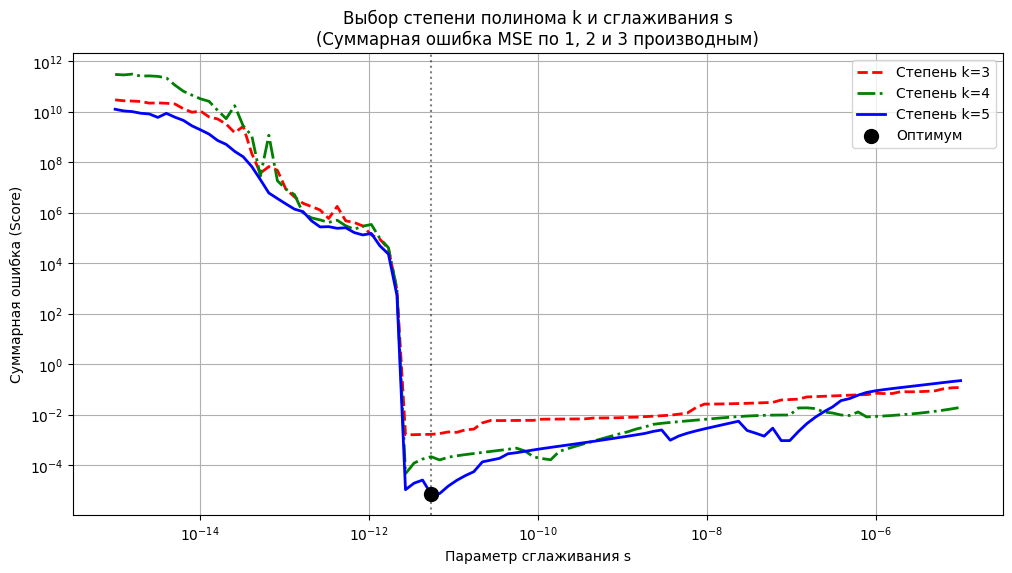

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from core.derivatives.spline import find_optimal_spline_params


s_grid = np.logspace(-15, -5, 100) # От 1e-15 до 1e-5
k_grid = [3, 4, 5]           

best_s, best_k, res_df = find_optimal_spline_params(
    df_stage2, 
    col_name='Eps_3', 
    time_col='Time_Local',
    analytic_obj=analytical,
    comp_idx=2,
    s_range=s_grid,
    k_range=k_grid
)

print(f"Оптимум: степень k={best_k}, Сглаживание s={best_s:.2e}")

plt.figure(figsize=(12, 6))

colors = {3: 'red', 4: 'green', 5: 'blue'}
styles = {3: '--', 4: '-.', 5: '-'}

for k in k_grid:
    subset = res_df[res_df['k'] == k]
    plt.loglog(subset['s'], subset['score'], 
               color=colors[k], linestyle=styles[k], linewidth=2, 
               label=f'Степень k={k}')

# Отмечаем оптимум
plt.axvline(best_s, color='k', linestyle=':', alpha=0.5)
plt.scatter([best_s], [res_df['score'].min()], color='black', s=100, zorder=5, label='Оптимум')

plt.title('Выбор степени полинома k и сглаживания s\n(Суммарная ошибка MSE по 1, 2 и 3 производным)')
plt.xlabel('Параметр сглаживания s')
plt.ylabel('Суммарная ошибка (Score)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

На основе проведенного анализа (Grid Search) были определены оптимальные значения гиперпараметров сплайна ($s_{opt}, k_{opt}$), обеспечивающие наилучший баланс между точностью аппроксимации и гладкостью высших производных.

Так как погрешности решателя ANSYS одинаковы для всех компонент деформаций, мы применяем найденные параметры для дифференцирования **всех компонент** вектора Ильюшина ($\ni_1, \ni_2, \ni_3$).

В результате для каждой компоненты вычисляются и сохраняются в DataFrame:
1.  **Скорость** ($\dot{\ni}$) — префикс `d`
2.  **Ускорение** ($\ddot{\ni}$) — префикс `d2`
3.  **Рывок** ($\dddot{\ni}$) — префикс `d3` (необходим для расчета кручения $\tau$)

In [78]:
from core.derivatives.spline import compute_spline_derivatives


components = ['Eps_1', 'Eps_2', 'Eps_3']
for col in components:
    d1, d2, d3 = compute_spline_derivatives(
        df_stage2, 
        col_name=col, 
        time_col='Time_Local', 
        s=best_s, 
        k=best_k
    )

    # Названия колонок: dEps_1_spline, d2Eps_1_spline, d3Eps_1_spline
    df_stage2[f'd{col}_spline'] = d1
    df_stage2[f'd2{col}_spline'] = d2
    df_stage2[f'd3{col}_spline'] = d3

Ниже представлены графики изменения компонент вектора деформаций $\ni_1$ и $\ni_3$, а также их вычисленных производных: скорости ($\dot{\ni}$), ускорения ($\ddot{\ni}$) и рывка ($\dddot{\ni}$).

*   **Компонента $\ni_1$** (соответствует осевой деформации $\varepsilon_z$) — отражает процесс растяжения/сжатия в ходе движения по винтовой траектории.
*   **Компонента $\ni_3$** (соответствует сдвигу $\varepsilon_{\theta z}$) — отражает процесс чистого кручения.

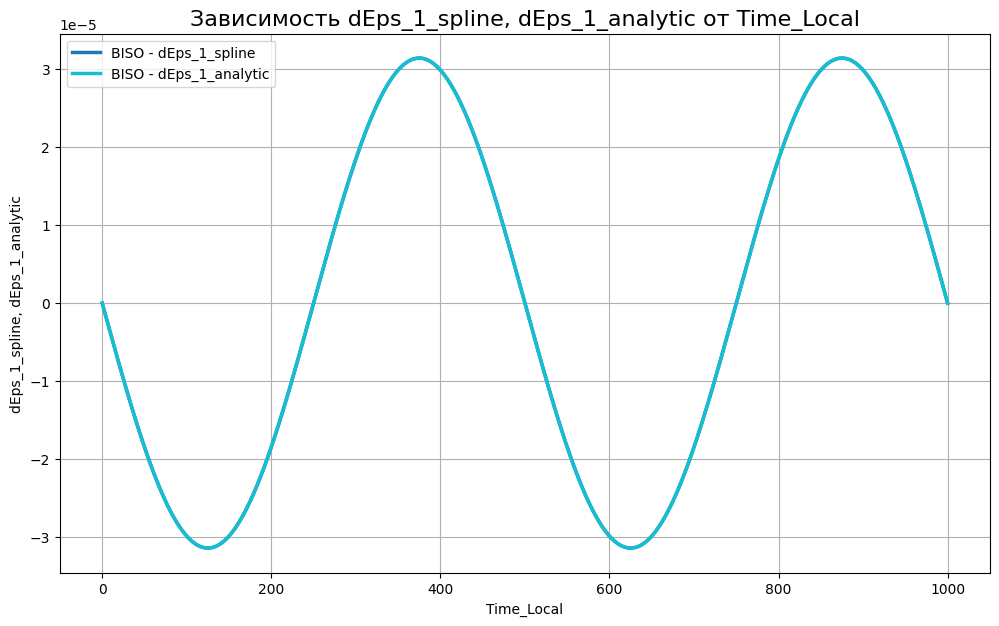

In [79]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col='Time_Local',
    y_cols=['dEps_1_spline', 'dEps_1_analytic'],
)

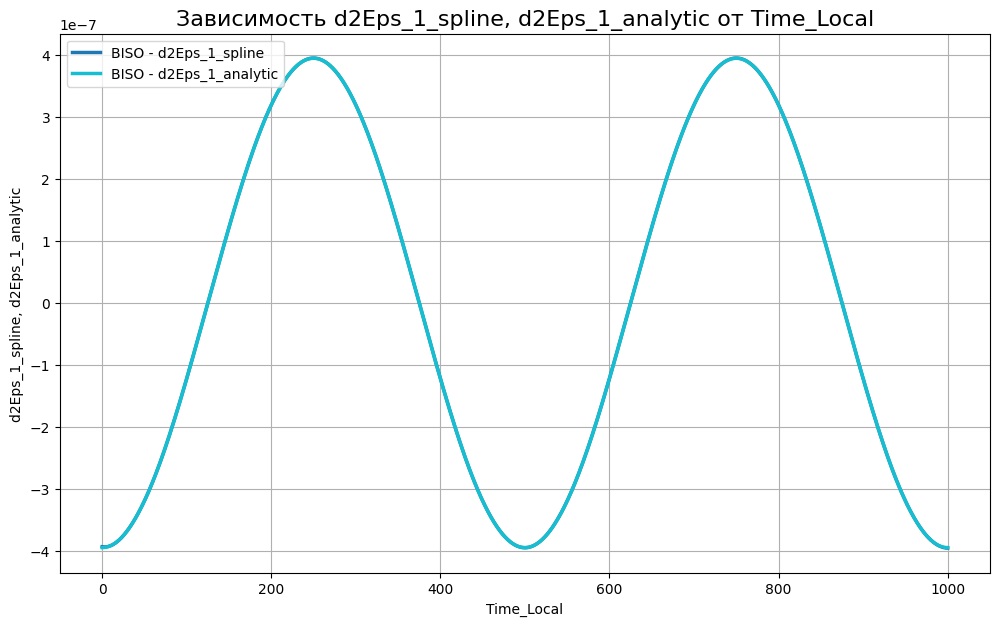

In [80]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col='Time_Local',
    y_cols=['d2Eps_1_spline', 'd2Eps_1_analytic'],
)

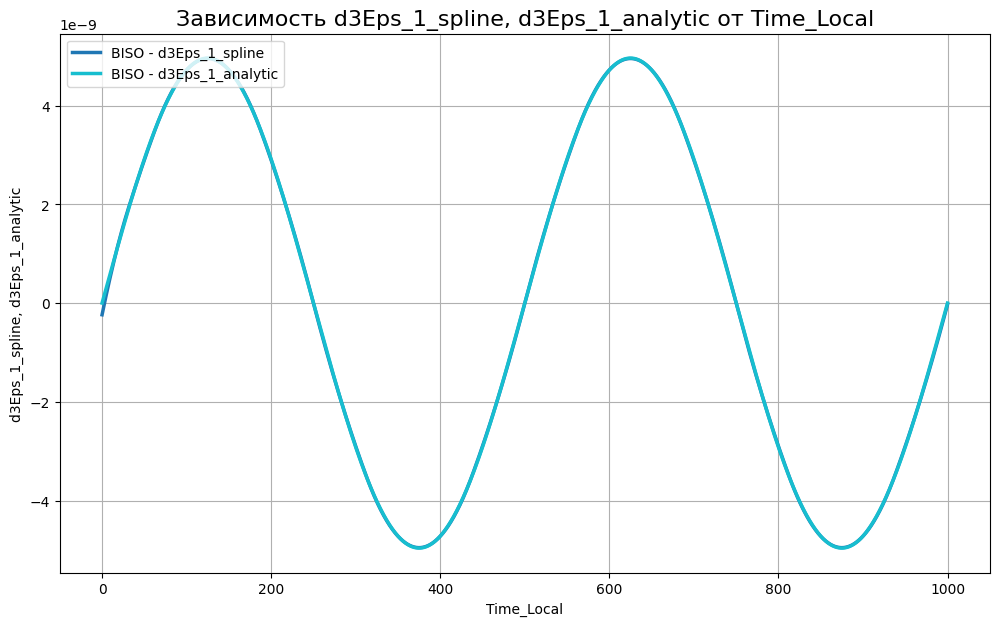

In [81]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col='Time_Local',
    y_cols=['d3Eps_1_spline', 'd3Eps_1_analytic'],
)

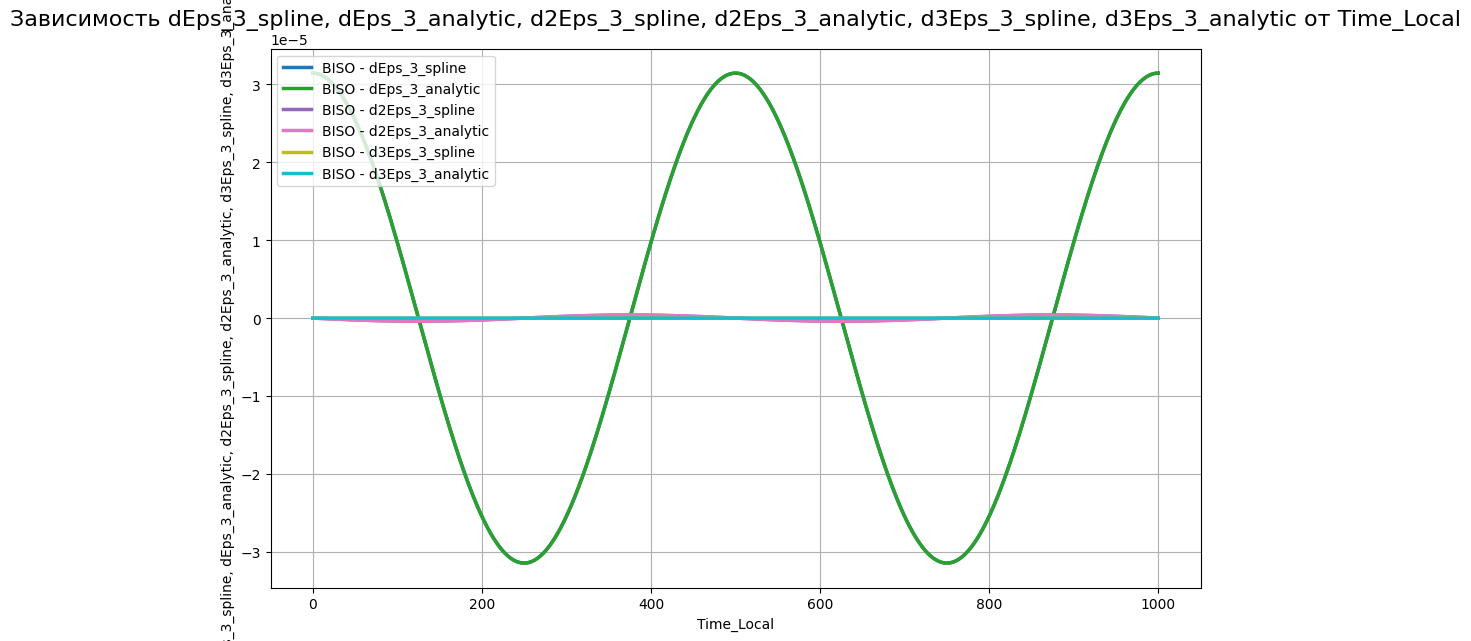

In [82]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col='Time_Local',
    y_cols=['dEps_3_spline',
            'dEps_3_analytic',
            'd2Eps_3_spline',
            'd2Eps_3_analytic',
            'd3Eps_3_spline',
            'd3Eps_3_analytic'
        ],
)